## 1. Import Necessary Library

In [1]:
pip install --upgrade certifi

Note: you may need to restart the kernel to use updated packages.


In [1]:
import ssl

ssl._create_default_https_context = ssl._create_unverified_context

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import keras
from keras.models import Sequential
from keras.layers import Dense,Flatten
from tensorflow.keras.datasets import cifar10

## 2. Data Collection

In [2]:
(X_train, y_train), (X_test, y_test) = keras.datasets.cifar10.load_data()


In [3]:

assert X_train.shape == (50000, 32, 32, 3)
assert X_test.shape == (10000, 32, 32, 3)
assert y_train.shape == (50000, 1)
assert y_test.shape == (10000, 1)
  

## 3. data Preparation

#### 3.1 Normalise the Data

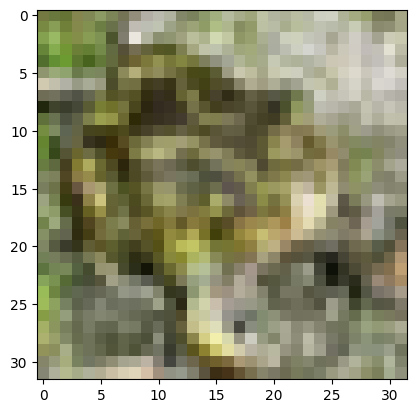

In [4]:
plt.imshow(X_train[143])

In [5]:
y_train[143]

array([6], dtype=uint8)

In [6]:
X_train.min(),X_train.max()

(np.uint8(0), np.uint8(255))

In [7]:
X_test.min(),X_test.max()

(np.uint8(0), np.uint8(255))

In [8]:
X_train_copy = X_train
X_test_copy = X_test
y_train_copy = y_train
y_test_copy = y_test

In [9]:
X_train = X_train/255
X_test = X_test/255

In [10]:
X_train.min(),X_train.max()

(np.float64(0.0), np.float64(1.0))

In [11]:
X_test.min(),X_test.max()

(np.float64(0.0), np.float64(1.0))

In [12]:
from keras.utils import to_categorical

In [13]:
y_train = to_categorical(y_train,num_classes = 10)

In [14]:
y_test = to_categorical(y_test,num_classes = 10)

In [15]:
y_train[143]

array([0., 0., 0., 0., 0., 0., 1., 0., 0., 0.])

## 4. Module Building

In [16]:
CF_Module = Sequential()

In [17]:
CF_Module.add(layer = Flatten(input_shape = (32,32,3))) ## Input Layer
CF_Module.add(Dense(units = 100,activation= "relu")) ## Hidden Layer 1
CF_Module.add(Dense(units = 50,activation= "relu")) ## Hidden Layer 2
CF_Module.add(Dense(units = 10,activation= "softmax"))

C:\Users\Lenovo\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [18]:
CF_Module.compile(optimizer='RMSprop',loss="CategoricalCrossentropy",metrics= ["accuracy"])

## 5. Module Training | Modele Test | Module Evaluation

In [19]:
CF_Module.fit(x=X_train,y=y_train,batch_size=50,epochs=10,validation_split = 0.2)

Epoch 1/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 14s 13ms/step - accuracy: 0.2804 - loss: 1.9884 - val_accuracy: 0.3140 - val_loss: 1.8741
Epoch 2/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.3577 - loss: 1.7903 - val_accuracy: 0.3839 - val_loss: 1.7243
Epoch 3/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.3850 - loss: 1.7171 - val_accuracy: 0.3976 - val_loss: 1.6947
Epoch 4/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.4025 - loss: 1.6680 - val_accuracy: 0.3953 - val_loss: 1.6996
Epoch 5/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.4140 - loss: 1.6341 - val_accuracy: 0.3985 - val_loss: 1.6918
Epoch 6/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.4262 - loss: 1.6044 - val_accuracy: 0.4256 - val_loss: 1.6101
Epoch 7/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.4369 - loss: 1.5806 - val_accuracy: 0.4273 - val_loss: 1.6146
Epoch 8/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.4438 - loss: 1.5579 - val

## 6. Module Manual Valudation

In [20]:
y_predict = CF_Module.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


In [24]:
np.argmax(y_predict[100])

np.int64(7)

In [25]:
np.argmax(y_test[100])

np.int64(4)

## 7. Deploy the Model

In [35]:
CF_Module.save("CF_Keras_intel.h5")